In [27]:
def one_way_plot_new(
    data, x_col, y_col, labels, n_bins=20, equal_size=False,
    add_na_bin=True, upper_cap=750000, cut=None, ax=None, total_ee=None, divide_ee=None,
    ylim=None, # <-- REVISION: Added ylim parameter to accept the global range
    output_file='./EDA_plot/data.xlsx', sheet_name=None
):
    """
    Bars: proportion of records per bin/category
    Line: per-bin series 'pp':
          - if divide_ee is True: EE-weighted mean of y
          - if divide_ee is False: simple (unweighted) mean of y
    """
    # If plotting simple mean, equal_size bins (by EE mass) don't make sense
    if divide_ee is False:
        equal_size = False

    # y and ee
    y_series = pd.to_numeric(data[y_col], errors="coerce")
    if upper_cap is not None:
        y_series = y_series.clip(lower=0, upper=upper_cap)
    y = y_series.to_numpy()

    ee = pd.to_numeric(data['ee'], errors="coerce").to_numpy()
    ee = np.where(np.isfinite(ee), ee, 0.0)

    x_raw = data[x_col]
    x_is_numeric = is_numeric_dtype(x_raw)
    if x_col == 'cape_yard_debris_coverage_sqft':
        print(f'cape_yard_debris_coverage_sqft is {x_is_numeric}')
    if x_col == 'state':
        print(f'state is {x_is_numeric}')

    pp, x_labels, x_hist = [], [], []

    if x_is_numeric:
        # ---------- numeric -----------
        x = pd.to_numeric(x_raw, errors="coerce").to_numpy()
        order = np.argsort(x.astype(float), kind="mergesort")
        x_sorted = x[order]
        y_sorted = y[order]
        ee_sorted = ee[order]

        ee_total = float(np.nansum(ee_sorted))
        if ee_total <= 0:
            # nothing to aggregate
            if ax is None:
                fig, ax1 = plt.subplots(figsize=(10, 6))
            else:
                ax1 = ax
            ax1.set_title(labels[2])
            ax1.set_xlabel(labels[0])
            ax1.set_ylabel("Proportion")
            ax1.text(0.5, 0.5, "Total EE is zero — nothing to plot.", ha="center", va="center")
            plt.tight_layout(); plt.show()
            return x_labels, x_hist, pp

        cum_ee = np.cumsum(ee_sorted) / ee_total
        groups = np.zeros_like(x_sorted, dtype=int)

        if equal_size:
            bin_edges = np.linspace(0, 1, n_bins + 1)
            bin_edges[-1] += 1e-12
            if add_na_bin:
                mask_num = np.isfinite(x_sorted)
                if mask_num.any():
                    scale = cum_ee[mask_num][-1]
                    tmp_cum = np.divide(cum_ee, scale, out=np.zeros_like(cum_ee), where=scale > 0)
                else:
                    tmp_cum = cum_ee
            else:
                tmp_cum = cum_ee
            for i in range(n_bins):
                groups[tmp_cum > bin_edges[i]] = i
        else:
            finite_mask = np.isfinite(x_sorted)
            if finite_mask.any():
                xmin = np.nanmin(x_sorted[finite_mask]); xmax = np.nanmax(x_sorted[finite_mask])
                if xmin == xmax:
                    bin_edges = np.array([xmin, xmin + 1e-12]); n_bins_eff = 1
                else:
                    bin_edges = np.linspace(xmin, xmax, n_bins + 1); n_bins_eff = n_bins
                bin_edges[-1] += 1e-12
                for i in range(n_bins_eff):
                    in_bin = (x_sorted >= bin_edges[i]) & (x_sorted < bin_edges[i + 1])
                    groups[in_bin] = i
                n_bins = n_bins_eff
            else:
                groups[:] = n_bins

        if add_na_bin:
            groups[~np.isfinite(x_sorted)] = n_bins

        G = n_bins + (1 if add_na_bin else 0)
        for g in range(G):
            idx = (groups == g)
            if not idx.any():
                continue

            if (cut is not None) and np.isfinite(cut):
                xmax_g = np.nanmax(x_sorted[idx]) if np.isfinite(x_sorted[idx]).any() else np.nan
                if np.isfinite(xmax_g) and xmax_g > cut:
                    break

            if g == n_bins and add_na_bin:
                x_labels.append("NaN")
            else:
                xmin_g = np.nanmin(x_sorted[idx]) if np.isfinite(x_sorted[idx]).any() else np.nan
                xmax_g = np.nanmax(x_sorted[idx]) if np.isfinite(x_sorted[idx]).any() else np.nan
                x_labels.append(f"{np.round(xmin_g, 3)} - {np.round(xmax_g, 3)}")

            y_bin, ee_bin = y_sorted[idx], ee_sorted[idx]
            ee_g = float(np.nansum(ee_bin))

            if divide_ee:
                # EE-weighted mean of y
                num = float(np.nansum(y_bin * ee_bin))
                val = (num / ee_g) if ee_g > 0 else np.nan
            else:
                # simple mean of y
                val = np.nanmean(y_bin) if y_bin.size else np.nan

            pp.append(val)
            x_hist.append(idx.sum() / x_sorted.shape[0] if x_sorted.shape[0] else 0.0)

    else:
        # ---------- categorical -----------
        x = x_raw.astype("string")
        if x_col == "state":
            desired_order = ["CT", "MA", "NH", "NJ", "NY", "PA"]
            present = set(x.dropna())
            cats = [c for c in desired_order if c in present] + sorted(present - set(desired_order))
        else:
            cats = sorted(set(x.dropna()))

        if x_col == "cape_roof_condition_rating":
            desired_order = ["-2", "-1", "0", "1", "2", "unknown"]
            cats = [c for c in desired_order if c in cats]

        n = len(x)

        for c in cats:
            mask = (x == c).fillna(False).to_numpy()
            if not mask.any():
                continue
            y_bin, ee_bin = y[mask], ee[mask]
            ee_g = float(np.nansum(ee_bin))

            if divide_ee:
                num = float(np.nansum(y_bin * ee_bin))
                val = (num / ee_g) if ee_g > 0 else np.nan
            else:
                val = np.nanmean(y_bin) if y_bin.size else np.nan

            pp.append(val)
            x_hist.append(mask.sum() / n if n else 0.0)
            x_labels.append(str(c))

        if add_na_bin and x.isna().any():
            mask_nan = x.isna().to_numpy()
            y_bin, ee_bin = y[mask_nan], ee[mask_nan]
            ee_g = float(np.nansum(ee_bin))
            if divide_ee:
                num = float(np.nansum(y_bin * ee_bin))
                val = (num / ee_g) if ee_g > 0 else np.nan
            else:
                val = np.nanmean(y_bin) if y_bin.size else np.nan
            pp.append(val)
            x_hist.append(mask_nan.sum() / n if n else 0.0)
            x_labels.append("NaN")

    # rescale bars vs global EE base
    if total_ee is not None:
        scale = (ee.sum() / total_ee) if total_ee else 0.0
        x_hist = [h * scale for h in x_hist]

    if output_file:
        try:
            # Create output directory if it doesn't exist
            output_dir = os.path.dirname(output_file)
            if output_dir and not os.path.exists(output_dir):
                os.makedirs(output_dir)
            
            # Prepare DataFrame
            df_out = pd.DataFrame({
                'Bin_Label': x_labels,
                'Frequency': x_hist,
                f'adj_PP': pp
            })
            
            # Determine Sheet Name
            if sheet_name:
                raw_sheet_name = str(sheet_name)
            else:
                raw_sheet_name = str(labels[0])
                
            # Clean sheet name (Excel limits sheet names to 31 chars and no special symbols)
            invalid_chars = [':', '/', '\\', '?', '*', '[', ']']
            for char in invalid_chars:
                raw_sheet_name = raw_sheet_name.replace(char, '_')
            final_sheet_name = raw_sheet_name[:31]

            # Write to Excel
            if os.path.exists(output_file):
                # Append to existing file
                with pd.ExcelWriter(output_file, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
                    df_out.to_excel(writer, sheet_name=final_sheet_name, index=False)
            else:
                # Create new file
                with pd.ExcelWriter(output_file, mode='w', engine='openpyxl') as writer:
                    df_out.to_excel(writer, sheet_name=final_sheet_name, index=False)
                    
        except Exception as e:
            print(f"Warning: Could not save data to Excel '{output_file}'. Error: {e}")
    # --- DATA SAVING LOGIC END ---


    # --- plotting ---
    positions = np.arange(len(x_labels))
    if ax is None:
        fig, ax1 = plt.subplots(figsize=(10, 6))
    else:
        ax1 = ax

    bars = ax1.bar(positions, x_hist, alpha=0.7, label='Count')
    ax1.set_ylabel("Frequency")
    # ax1.set_ylim(0, min(max(x_hist) * 1.3, 1) if x_hist else 1.0)
    m = np.nanmax(np.asarray(x_hist, float))  # max of your data
    y_top = next((t for t in (0.3, 0.5, 0.7, 1.0) if m <= t), 1.0)
    ax1.set_ylim(0, y_top)
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    (line,) = ax2.plot(positions, pp, marker='o', label='Line', color='r')
    ax2.set_ylabel(labels[1] + (" (EE-weighted mean)" if divide_ee else " (mean)"))
    ax2.tick_params(axis='y', labelcolor='black')

    # --- REVISION: Apply the ylim if it was passed ---
    if ylim is not None and len(ylim) == 2:
        ax2.set_ylim(ylim)
    # --- End Revision ---

    ax1.set_xticks(positions)
    ax1.set_xticklabels(x_labels, rotation=75)
    ax1.set_xlabel(labels[0] + (" (By Equal Earned Exposure Split)" if (x_is_numeric and equal_size) else ""))
    ax1.set_title(labels[2])

    ax1.legend([bars, line], ['Frequency', labels[1]+' avg'], loc='upper left')
    plt.tight_layout(); plt.show()
    return x_labels, x_hist, pp

In [6]:
v5_train = pd.read_csv(f'./v5_datasets/train.csv')
v4_train = pd.read_csv(f'./v4_datasets/train.csv')

In [12]:
v4_train.columns

Index(['Unnamed: 0', 'cape_response_status', 'cape_response_description',
       'cape_response_id', 'cape_primary_structure_latitude',
       'cape_primary_structure_longitude', 'attribute_geometry_id',
       'cape_parcel_id', 'cape_oblique_property_date',
       'cape_oblique_property_image_source',
       ...
       'zip4', 'year', 'tv', 'form', 'cumulative_inflation_factor',
       'ncat_infl_adj', 'pp_infl_adj', 'p0_alxc_wo_cape_pred', 'pp',
       '_state_num_'],
      dtype='object', length=123)

Y-axis range (ncat/ee) from v5_train set to: (0, 1300)
----------------------------------------

--- Processing v4_train ---


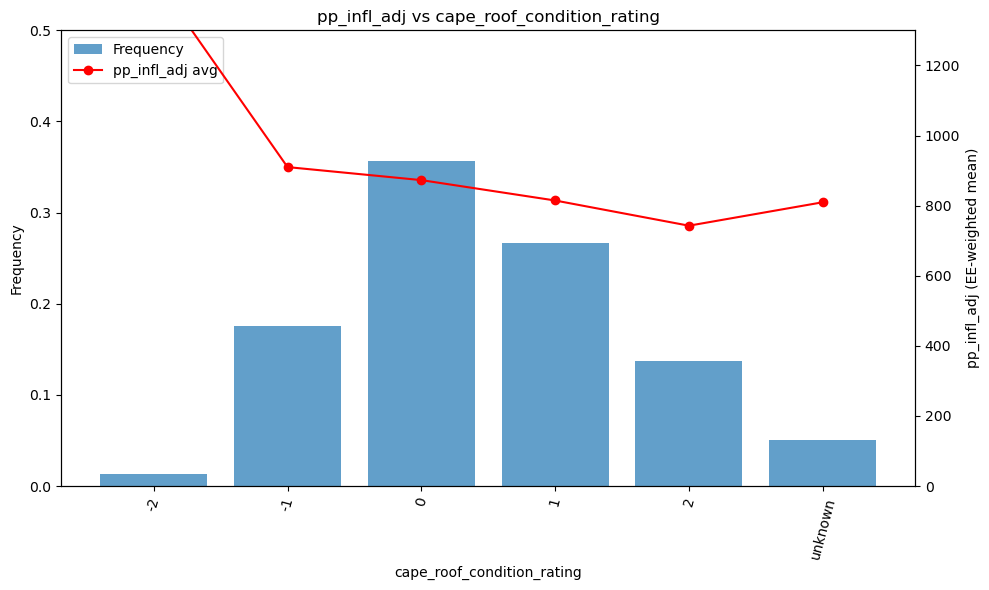

cape_yard_debris_coverage_sqft is True


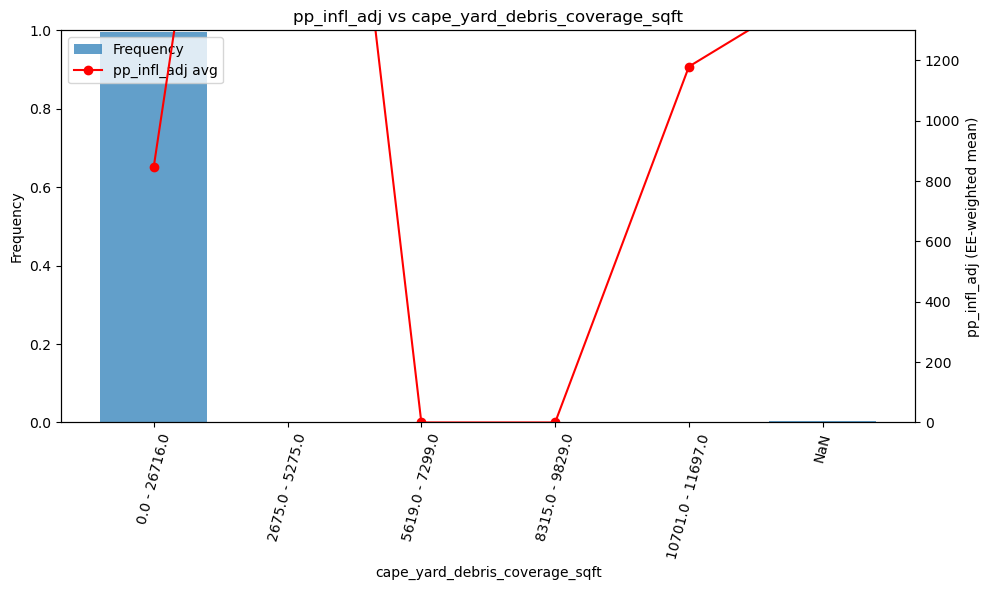

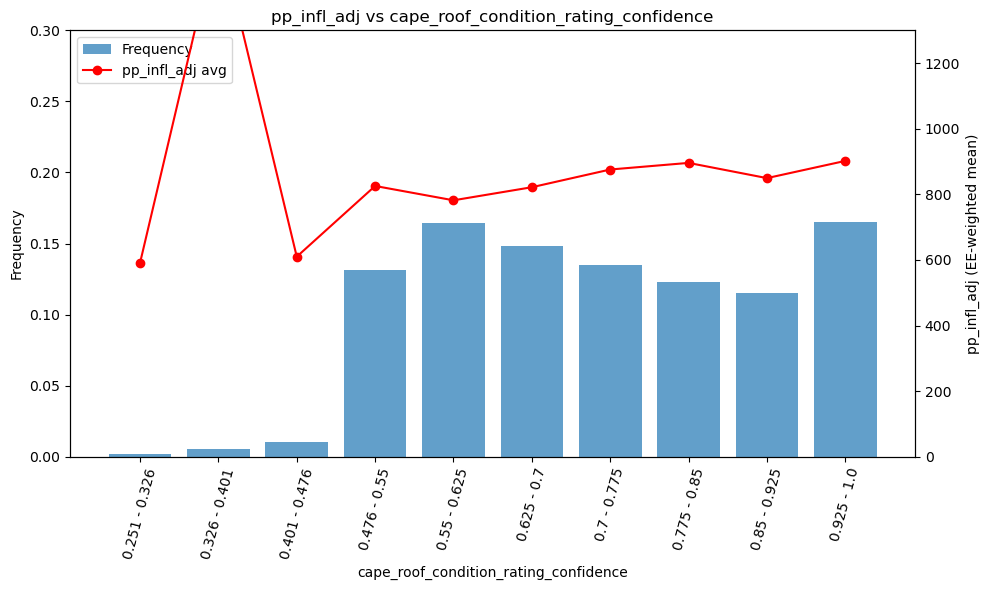

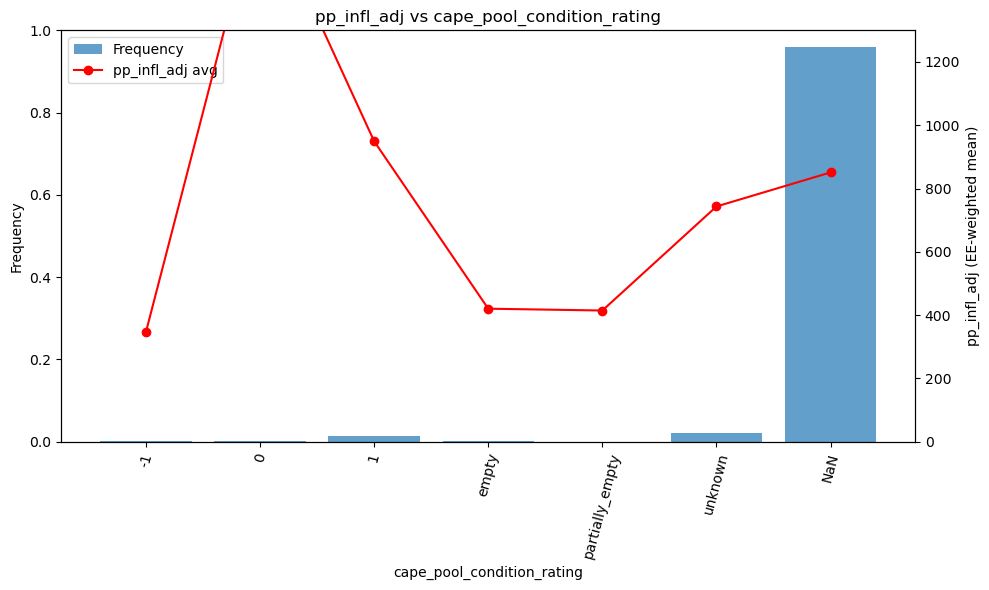

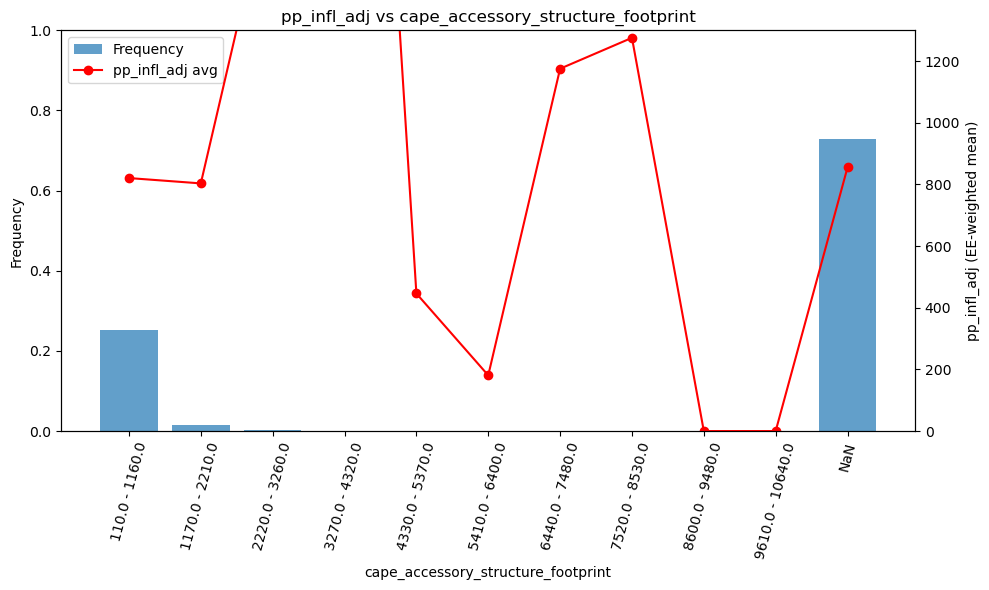

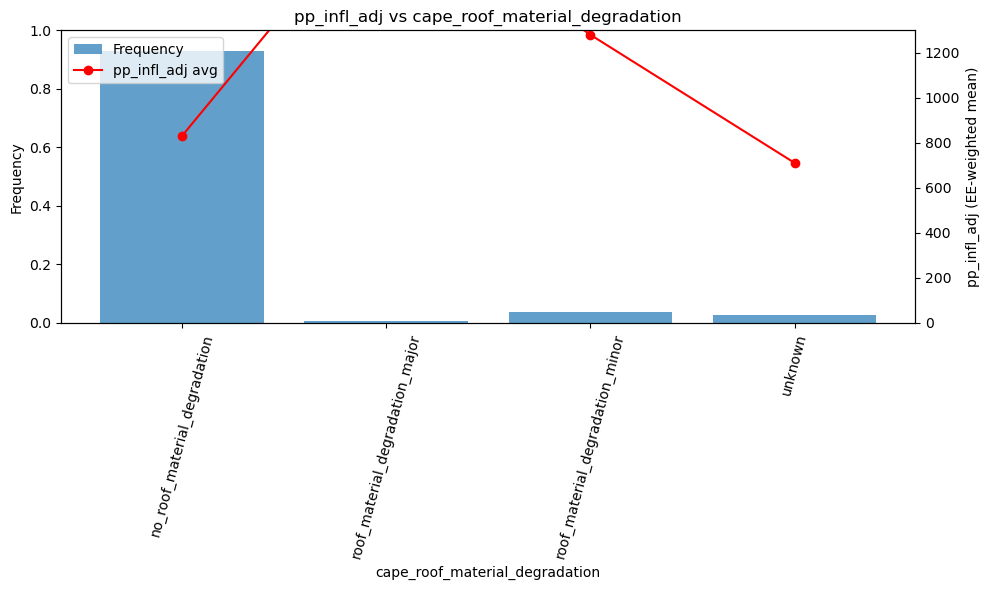

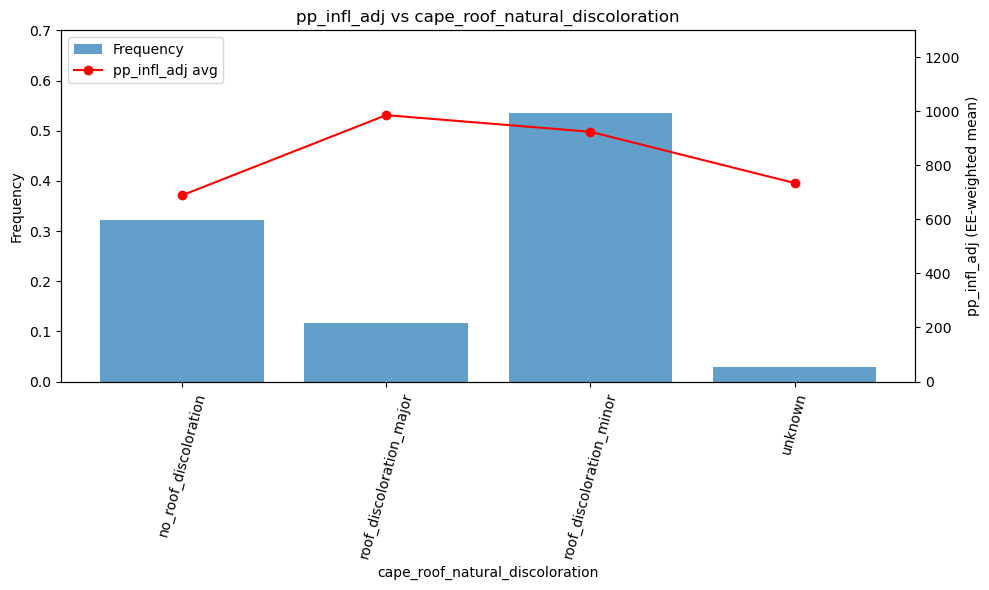

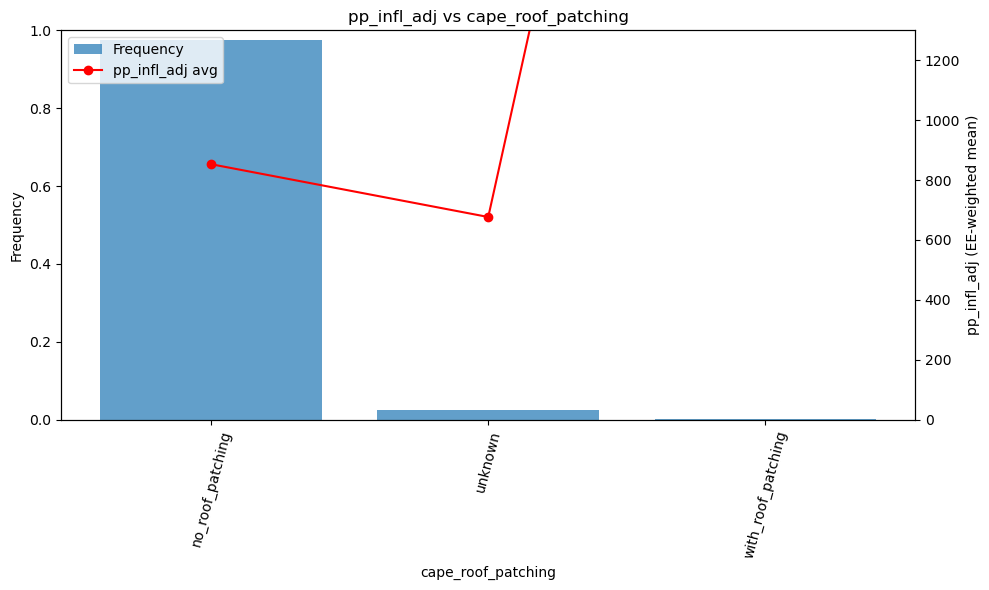

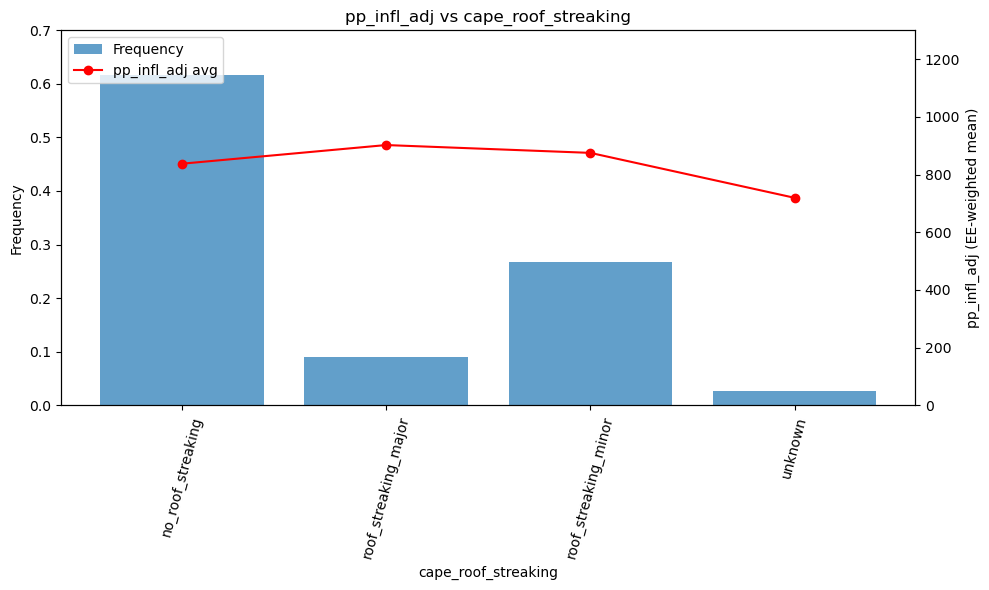

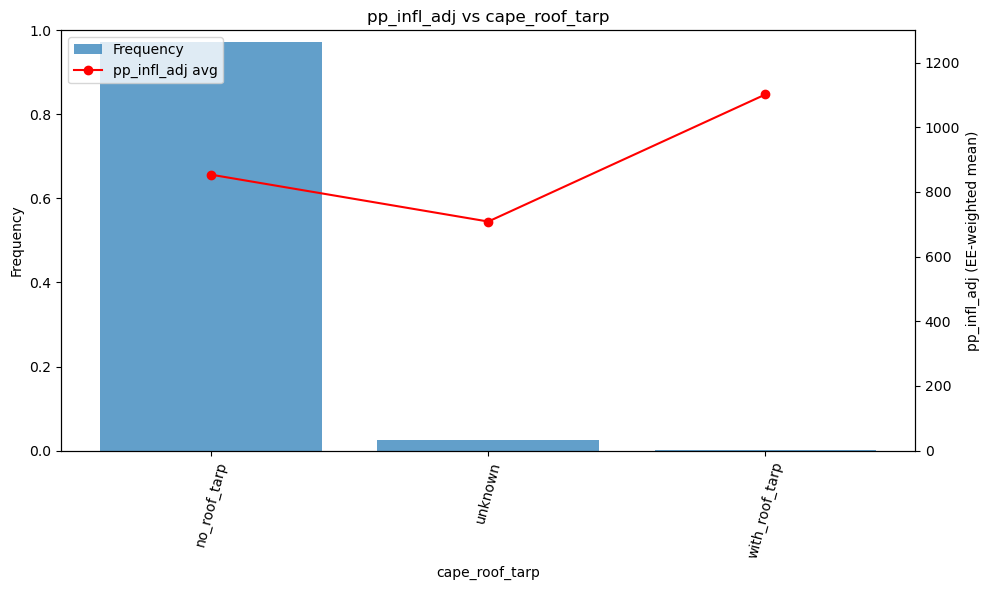

state is False


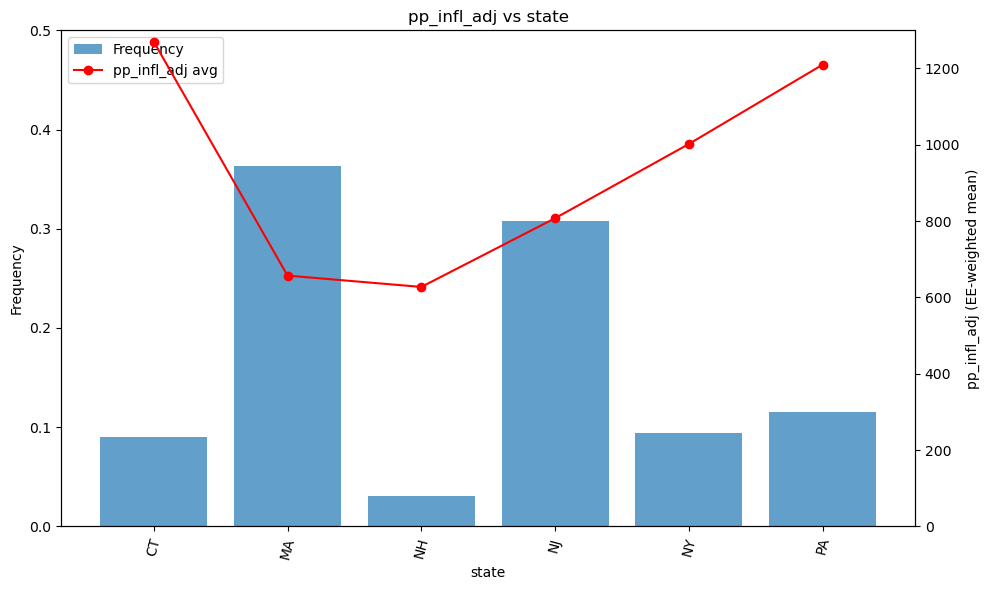


--- Processing v5_train ---


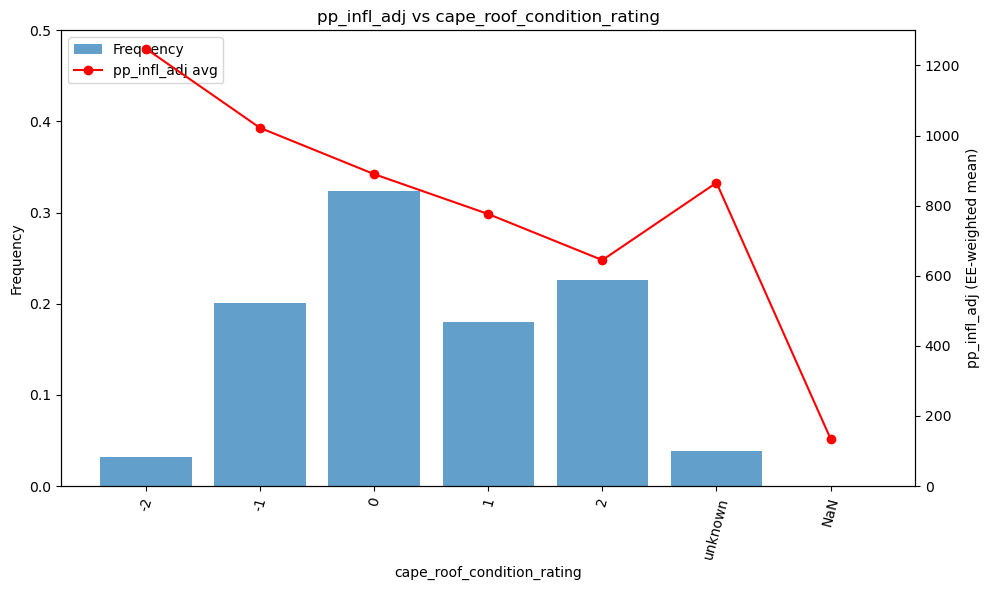

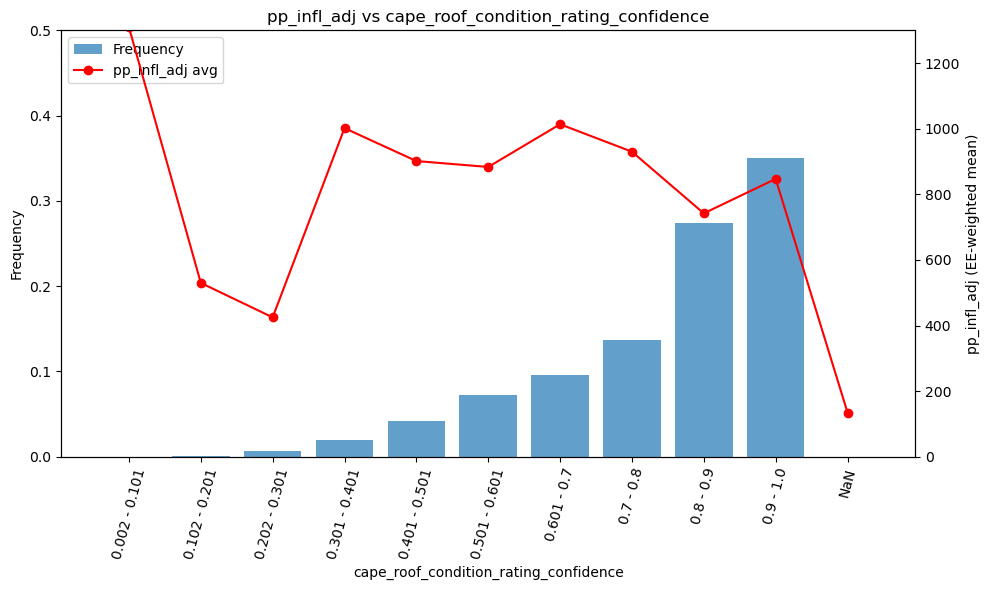

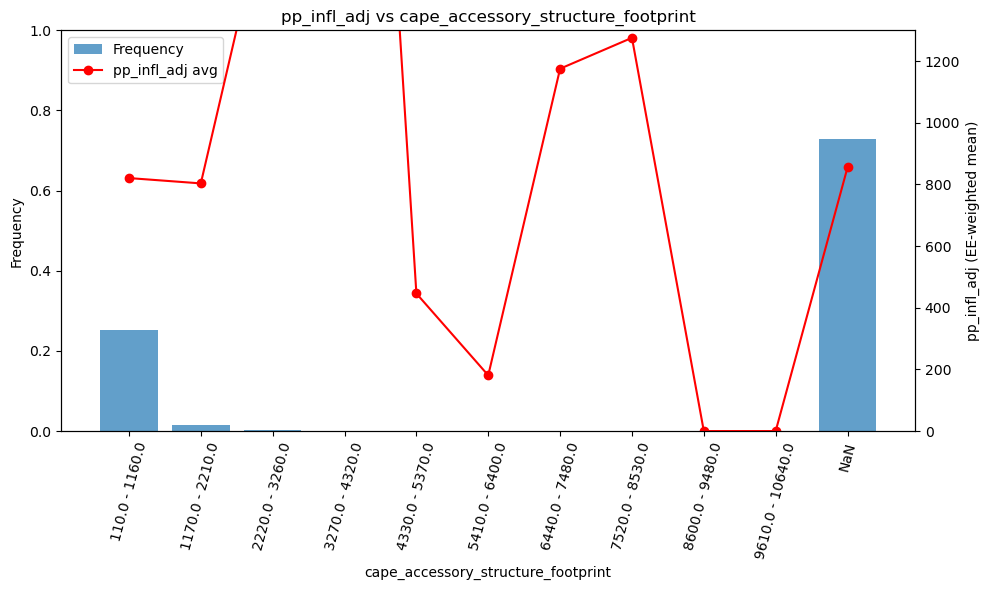

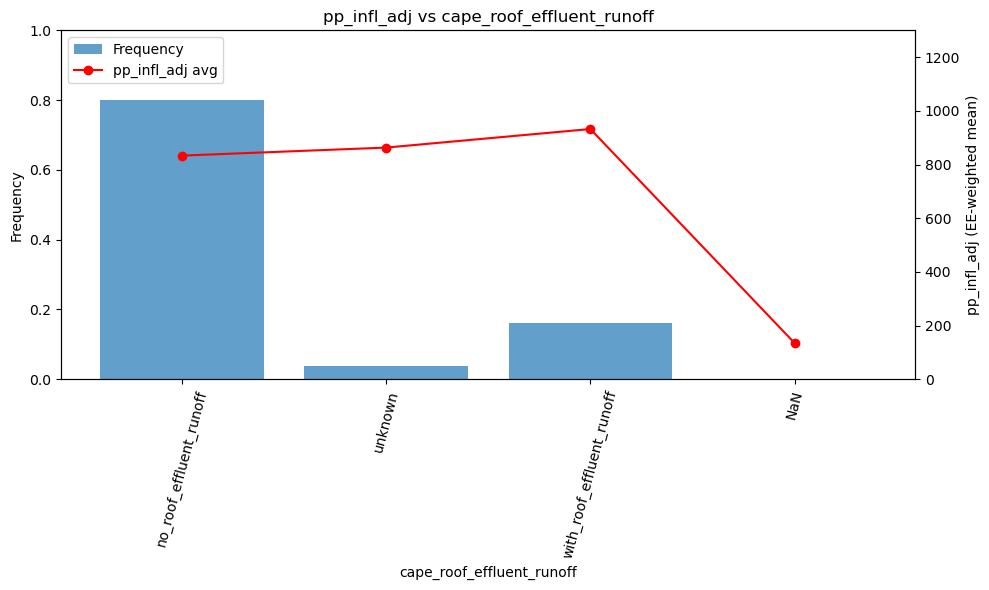

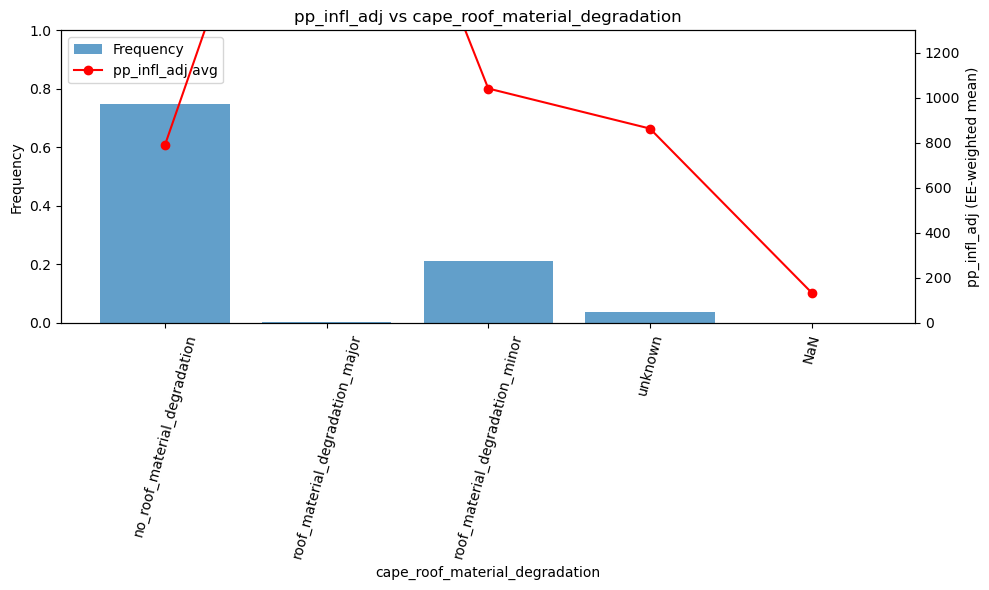

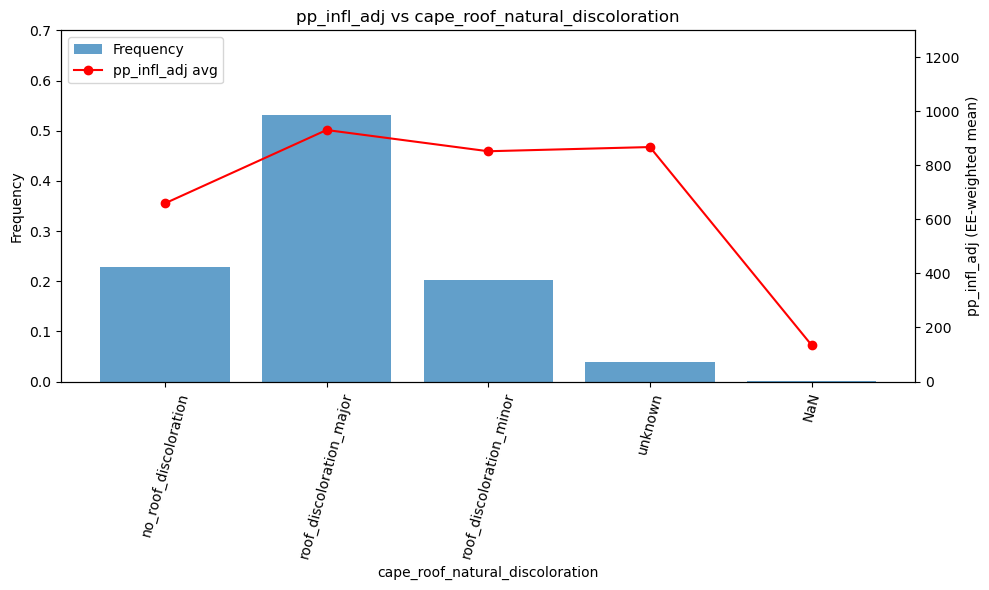

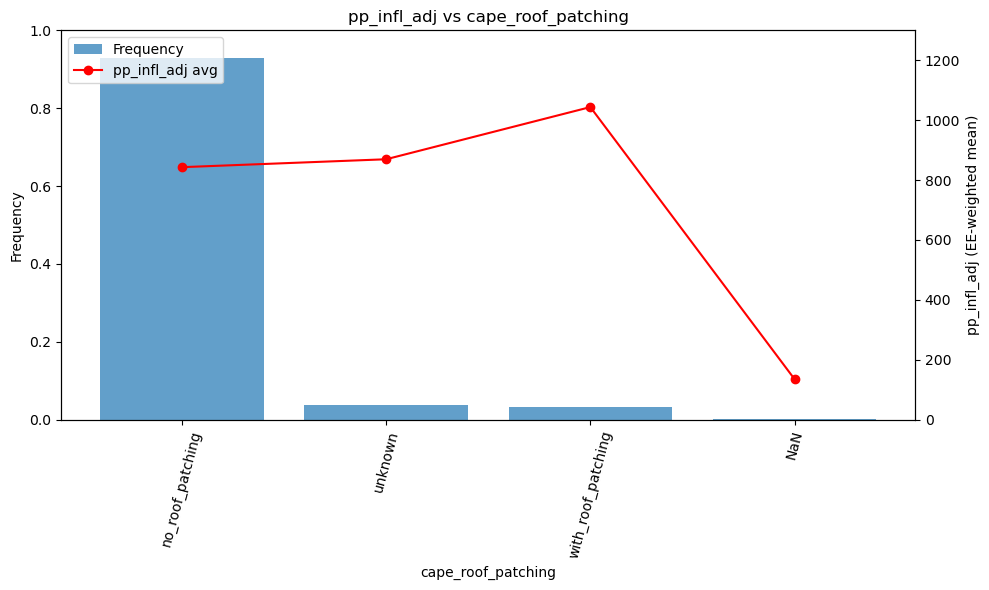

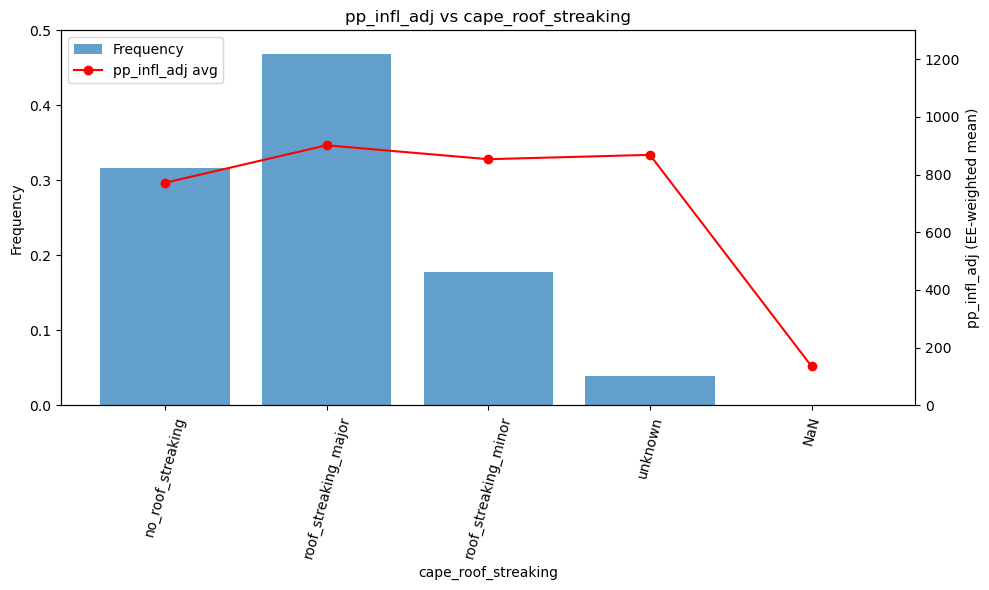

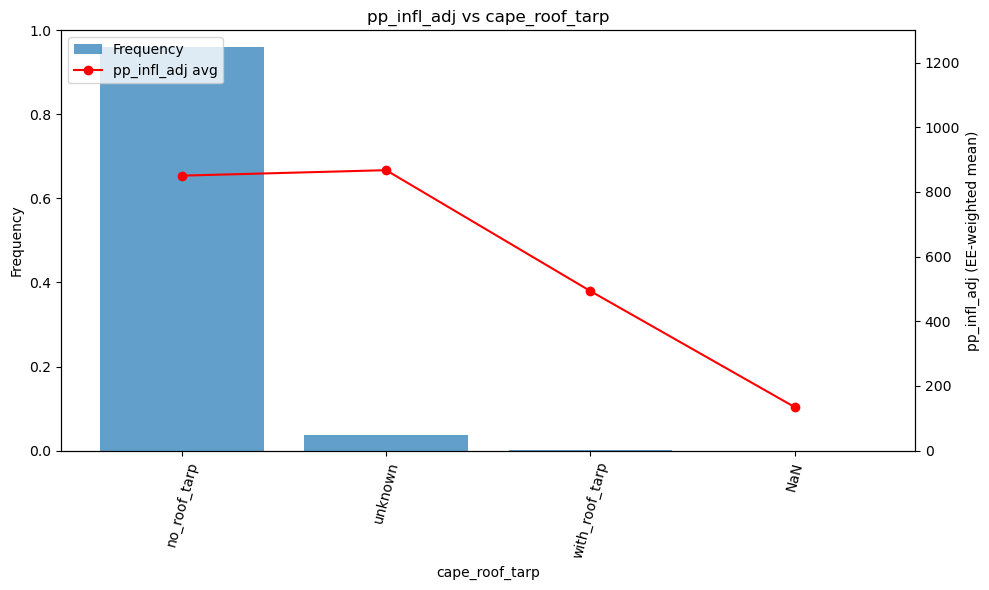

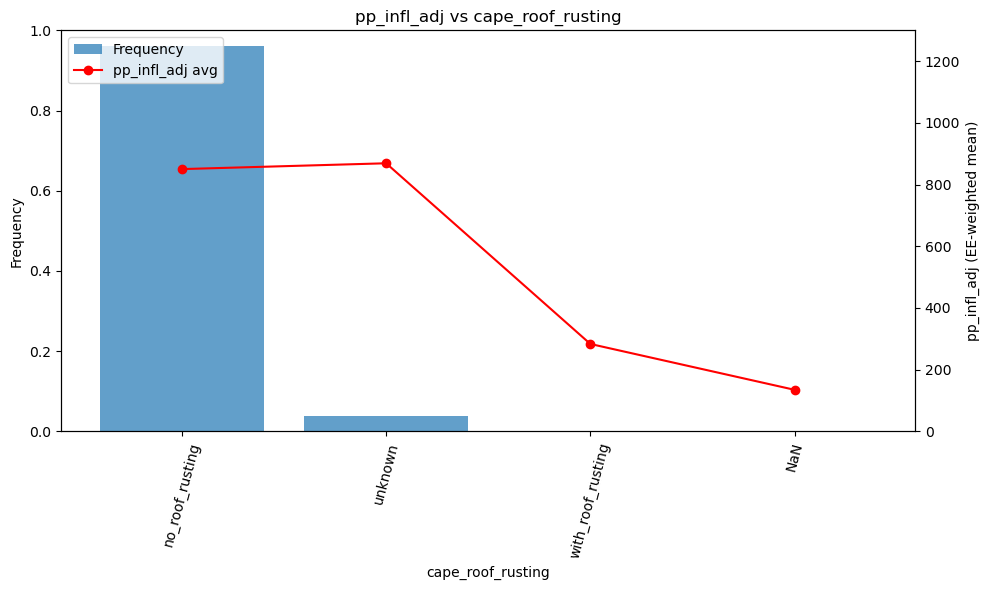

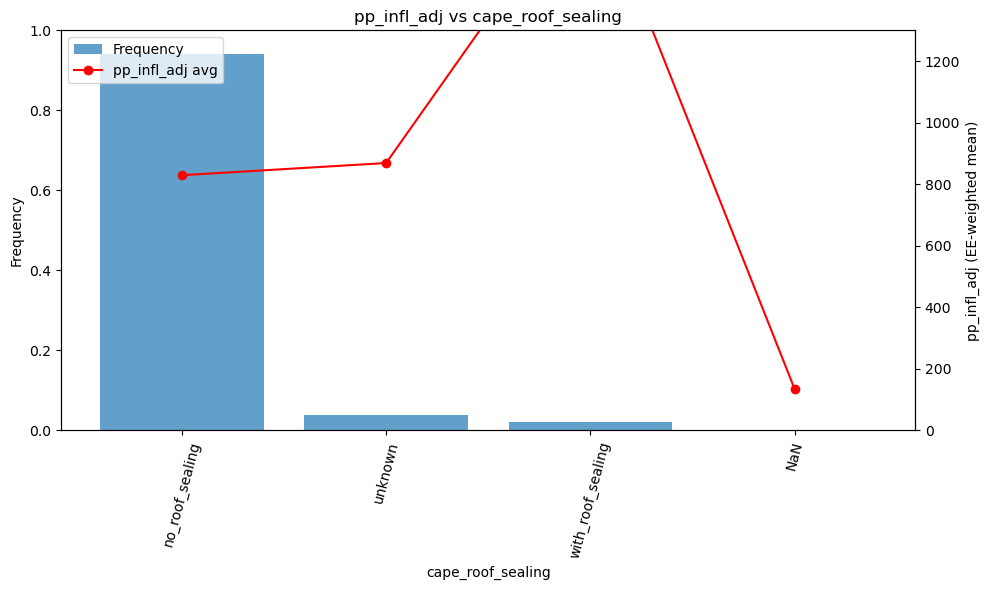

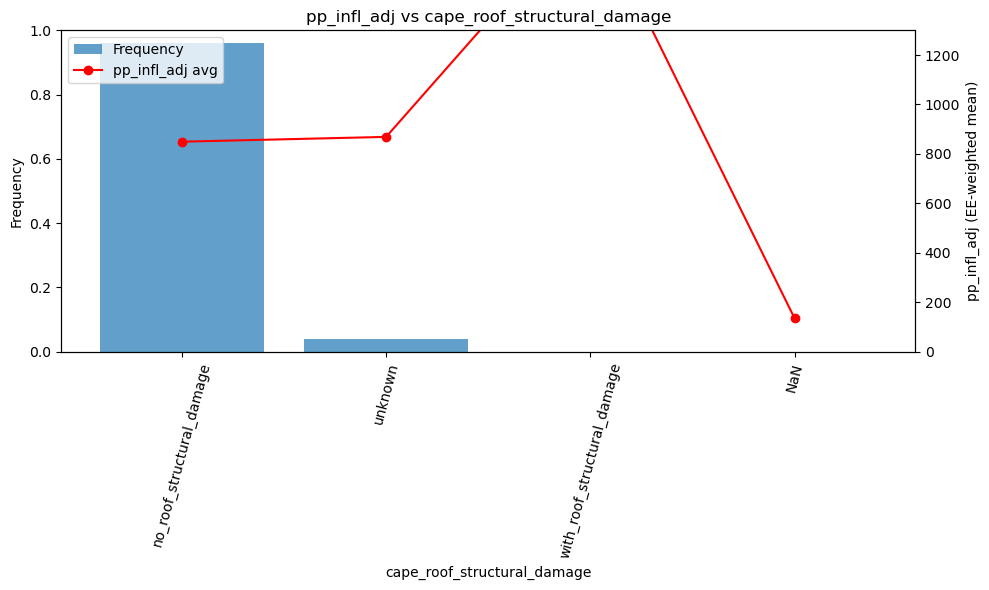

state is False


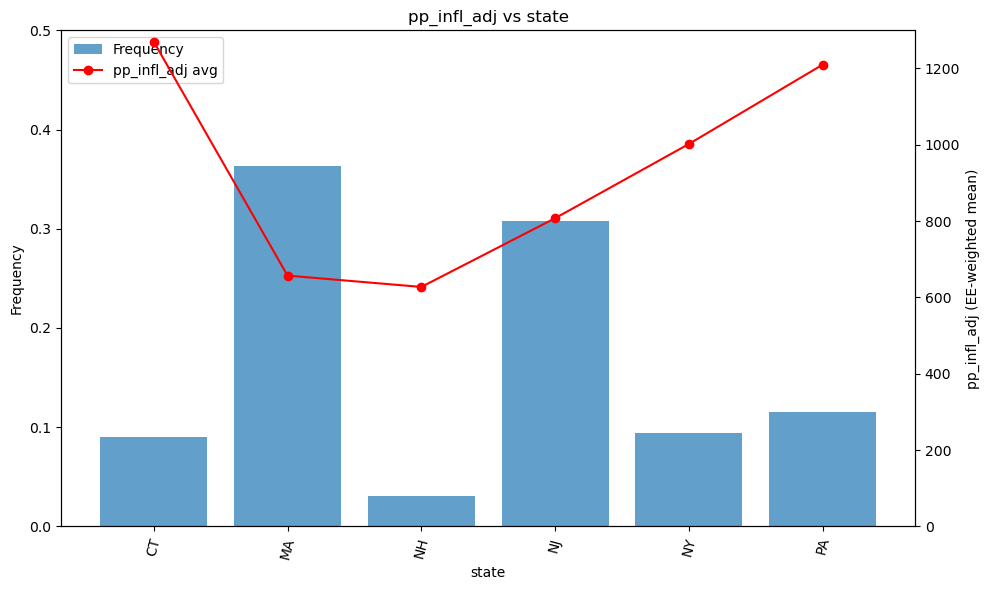

In [28]:
import os as os
# --- 2. Calculate the 'pp' (ncat/ee) column for both dataframes ---
# This column will be used to find the global range
v5_train['pp'] = v5_train['ncat_infl_adj'] / v5_train['ee']
v4_train['pp'] = v4_train['ncat_infl_adj'] / v4_train['ee']

# --- 3. Find the global min/max range for 'pp' across both dataframes ---
# Concatenate the 'pp' series from both
v5_pp = v5_train['pp'] # Use only v5_train for the range

# Replace infinite values (from division by zero) with NaN so they are ignored
# all_pp.replace([np.inf, -np.inf], np.nan, inplace=True)
v5_pp.replace([np.inf, -np.inf], np.nan, inplace=True)


# Get the min and max, ignoring NaN values
# global_min = all_pp.min()
# global_max = all_pp.max()
# global_range = (global_min, global_max) # This is the range to apply to plots
v5_min = v5_pp.min()
v5_max = v5_pp.max()
v5_range = (0, 1300) # This is the range to apply to all plots


# print(f"Global Y-axis range (ncat/ee) set to: {global_range}")
print(f"Y-axis range (ncat/ee) from v5_train set to: {v5_range}")
print("-" * 40)

# --- 4. Set up plot variables ---
# Define separate x-axis lists for v4 and v5
# (Using the lists from your original script)
xaxises_v4 = ['cape_roof_condition_rating', 'cape_yard_debris_coverage_sqft', 'cape_roof_condition_rating_confidence',
              'cape_pool_condition_rating', 'cape_accessory_structure_footprint',
              'cape_roof_material_degradation', 'cape_roof_natural_discoloration',
              'cape_roof_patching', 'cape_roof_streaking', 'cape_roof_tarp', 'state'] # Added 'state'

xaxises_v5 = ['cape_roof_condition_rating',  'cape_roof_condition_rating_confidence',
              'cape_accessory_structure_footprint', 'cape_roof_effluent_runoff',
              'cape_roof_material_degradation', 'cape_roof_natural_discoloration',
              'cape_roof_patching', 'cape_roof_streaking', 'cape_roof_tarp', 'cape_roof_rusting',
              'cape_roof_sealing', 'cape_roof_structural_damage', 'state'] # Added 'state'

# This list will hold the correct xaxises for each var
# We'll pair the var with its specific x-axis list
vars_and_xaxises = [
    (v4_train, xaxises_v4),
    (v5_train, xaxises_v5)
]

# --- 5. Update yaxises to 'ncat' ---
# The plot function's `divide_ee=True` will handle the '/ ee' part
# The y-axis *label* will be 'ncat', but its *value* will be ncat/ee
yaxises = ['pp_infl_adj']

STATE_ORDER = ["CT", "MA", "NH", "NJ", "NY", "PA"]
state2code = {s:i for i, s in enumerate(STATE_ORDER)}

# --- 6. Loop and plot ---
# We loop through the (var, xaxis_list) pairs
for i, (var, xaxises) in enumerate(vars_and_xaxises):
    var_name = "v4_train" if i == 0 else "v5_train"
    print(f"\n--- Processing {var_name} ---")
    
    for xaxis in xaxises:
        current_xaxis_col = xaxis # Store original xaxis name
        
        # if xaxis == 'state':
        #     tmp_col = "_state_num_"
        #     # keep only the six states (others become NaN and are dropped by binning logic)
        #     vstate = var["state"].astype(str).str.upper()
        #     var[tmp_col] = vstate.map(state2code).astype("float")  # float so it plays nice with numpy
        #     current_xaxis_col = tmp_col # Use the new numeric column for plotting
        
        for yaxis in yaxises:
            # We check the original 'xaxis' variable to decide if we should plot
            # Your original logic skipped plotting for 'state'
            # Note: The plot function still gets the original 'xaxis' name for labels
                # --- 7. Pass the v5_range to the plot function ---
                # This call will now work correctly
            _ = one_way_plot_new(var, current_xaxis_col, yaxis, 
                                labels=[xaxis, yaxis, yaxis + ' vs '+xaxis ],
                                n_bins=10, 
                                equal_size=False,
                                add_na_bin=True, 
                                divide_ee=True,
                                # ylim=global_range) # <--- This now works
                                ylim=v5_range,
                                output_file = './EDA_plot/' + var_name+'.xlsx',) # <--- Use v5_range for all plots

                # If you DO want to plot 'state' (vs. _state_num_), you'd call
                # one_way_plot_new here, likely with `current_xaxis_col = '_state_num_'`
                # and the `xaxis = 'state'` for the label.